## 1 Importation bibliothèques

In [39]:
#%pip install seaborn
#%pip install pandas
#%pip install numpy
#%pip install matplotlib

import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

In [40]:
#%pip install scikit-learn
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)

from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn import tree


## 2 Chargement données et aperçu

In [41]:
data_smoke_drink = pd.read_csv("BDD_initial/addiction_population_data.csv", sep=",", index_col=0)
data_smoke_drink.head()

,name,age,gender,country,city,education_level,employment_status,annual_income_usd,marital_status,children_count,...,has_health_issues,mental_health_status,exercise_frequency,diet_quality,sleep_hours,bmi,social_support,therapy_history,addict_smoke,addict_drink
id,,,,,,,,,,,,,,,,,,,,,
1,Michael Bates,66,Other,Yemen,Martinmouth,Secondary,Student,45595,Married,3,...,True,Good,Daily,Average,5.6,22.4,NaN,Current,0,0
2,Brian Thompson,29,Male,Saudi Arabia,Harperhaven,Primary,Self-Employed,145842,Single,4,...,False,Poor,Weekly,Good,6.7,24.1,Moderate,NaN,1,0
3,Steven Little,75,Male,Togo,Chanport,Postgraduate,Unemployed,162480,Single,5,...,True,Good,Never,Good,6.2,22.2,Weak,NaN,1,0
4,Michael Mathews,35,Other,Togo,North Cory,University,Unemployed,16023,In a relationship,3,...,False,Average,Daily,Good,7.2,25.5,Moderate,Current,0,0
5,Nicholas Sanchez,38,Female,Morocco,Danielberg,College,Self-Employed,62933,In a relationship,0,...,True,Poor,Weekly,Good,8.5,31.2,Weak,Past,0,0


In [42]:
y = data_smoke_drink["smokes_per_day"]
categorical_cols = data_smoke_drink.drop(["smokes_per_day","addict_smoke","name","country","city","addict_drink"],axis=1).columns
data_smoke = data_smoke_drink.drop(["smokes_per_day","addict_smoke","name","country","city","addict_drink"],axis=1)
categorical_cols


Index(['age', 'gender', 'education_level', 'employment_status',
       'annual_income_usd', 'marital_status', 'children_count',
       'drinks_per_week', 'age_started_smoking', 'age_started_drinking',
       'attempts_to_quit_smoking', 'attempts_to_quit_drinking',
       'has_health_issues', 'mental_health_status', 'exercise_frequency',
       'diet_quality', 'sleep_hours', 'bmi', 'social_support',
       'therapy_history'],
      dtype='str')

In [43]:
print(data_smoke.dtypes)
print(data_smoke.isnull().sum())
data_smoke.describe()

age                            int64
gender                           str
education_level                  str
employment_status                str
annual_income_usd              int64
marital_status                   str
children_count                 int64
drinks_per_week                int64
age_started_smoking            int64
age_started_drinking           int64
attempts_to_quit_smoking       int64
attempts_to_quit_drinking      int64
has_health_issues               bool
mental_health_status             str
exercise_frequency               str
diet_quality                     str
sleep_hours                  float64
bmi                          float64
social_support                   str
therapy_history                  str
dtype: object
age                             0
gender                          0
education_level               420
employment_status               0
annual_income_usd               0
marital_status                  0
children_count                  0
drinks_p

,age,annual_income_usd,children_count,drinks_per_week,age_started_smoking,age_started_drinking,attempts_to_quit_smoking,attempts_to_quit_drinking,sleep_hours,bmi
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,46.654333,98904.178000,2.453667,5.002333,24.365667,24.525333,4.440333,4.542000,6.470400,25.170133
std,18.740880,57288.035963,1.704354,2.214037,8.707309,8.679121,2.835334,2.866992,1.495878,5.013345
min,15.000000,560.000000,0.000000,0.000000,10.000000,10.000000,0.000000,0.000000,1.500000,9.100000
25%,31.000000,49336.000000,1.000000,3.000000,17.000000,17.000000,2.000000,2.000000,5.475000,21.900000
50%,47.000000,98616.500000,2.000000,5.000000,24.000000,25.000000,4.000000,5.000000,6.500000,25.200000
75%,63.000000,148622.750000,4.000000,6.000000,32.000000,32.000000,7.000000,7.000000,7.500000,28.400000
max,79.000000,199951.000000,5.000000,14.000000,39.000000,39.000000,9.000000,9.000000,12.600000,43.900000


## 3 Prétraitement des données

In [44]:
data = data_smoke.copy()

#variables à transformer de texte en nombre

categorical_cols = data.select_dtypes(include='object').columns
print(f"Variables catégorielles à encoder : {list(categorical_cols)}")

Variables catégorielles à encoder : ['gender', 'education_level', 'employment_status', 'marital_status', 'mental_health_status', 'exercise_frequency', 'diet_quality', 'social_support', 'therapy_history']


C:\Users\sidsm\AppData\Local\Temp\ipykernel_9684\560342484.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include='object').columns


In [45]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nAperçu après encodage :")
data.head()

  gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
  education_level: {'College': np.int64(0), 'High School': np.int64(1), 'Postgraduate': np.int64(2), 'Primary': np.int64(3), 'Secondary': np.int64(4), 'University': np.int64(5), nan: np.int64(6)}
  employment_status: {'Employed': np.int64(0), 'Retired': np.int64(1), 'Self-Employed': np.int64(2), 'Student': np.int64(3), 'Unemployed': np.int64(4)}
  marital_status: {'Divorced': np.int64(0), 'In a relationship': np.int64(1), 'Married': np.int64(2), 'Single': np.int64(3), 'Widowed': np.int64(4)}
  mental_health_status: {'Average': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}
  exercise_frequency: {'Daily': np.int64(0), 'Never': np.int64(1), 'Rarely': np.int64(2), 'Weekly': np.int64(3)}
  diet_quality: {'Average': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}
  social_support: {'Moderate': np.int64(0), 'Strong': np.int64(1), 'Weak': np.int64(2), nan: np.int64(3)}
  therapy_history: {'Current': np

,age,gender,education_level,employment_status,annual_income_usd,marital_status,children_count,drinks_per_week,age_started_smoking,age_started_drinking,attempts_to_quit_smoking,attempts_to_quit_drinking,has_health_issues,mental_health_status,exercise_frequency,diet_quality,sleep_hours,bmi,social_support,therapy_history
id,,,,,,,,,,,,,,,,,,,,
1,66,2,4,3,45595,2,3,4,12,29,6,2,True,1,0,0,5.6,22.4,3,0
2,29,1,3,2,145842,3,4,3,11,24,1,6,False,2,3,1,6.7,24.1,0,2
3,75,1,2,4,162480,3,5,4,18,27,9,9,True,1,1,1,6.2,22.2,2,2
4,35,2,5,4,16023,1,3,4,37,14,5,7,False,0,0,1,7.2,25.5,0,0
5,38,0,0,2,62933,1,0,2,20,35,4,7,True,2,3,1,8.5,31.2,2,1


## 4 Entrainement de différents modèles d'apprentissage

La première méthode consiste à effectuer l'entrainement des données à l'aide de la fonction 'cross_val_score' qui sépare le jeu de donnée en 'cv=4' groupe avant d'entrainer les données sur chacun d'entre eux et tester son score sur le dernier groupe.

In [46]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

clf = DecisionTreeClassifier(max_depth=1, min_samples_split=2)
scores = cross_val_score(clf, data, y, cv=4)
scores.mean()
print(scores)
print(scores.mean())

clf = RandomForestClassifier(n_estimators=100, max_depth=1,
    min_samples_split=2)
scores = cross_val_score(clf, data, y, cv=4)
scores.mean()
print(scores)
print(scores.mean())

clf = ExtraTreesClassifier(n_estimators=10, max_depth=1,
    min_samples_split=2)
scores = cross_val_score(clf, data, y, cv=4)
print(scores)
print(scores.mean())

scores.mean() > 0.999

[0.136      0.136      0.13466667 0.11333333]
0.13
[0.13733333 0.136      0.13466667 0.13466667]
0.13566666666666666
[0.13733333 0.136      0.136      0.136     ]
0.13633333333333333


np.False_

Les modèles ne dépassent pas 13.7 % de prédiction, ce qui est très mauvais.

Pour les modèles suivant, nous avons séparé les données en 2 groupes : 1 train set qui comprend 80% du jeu de donnée et un test split qui contient 20% du jeu de donnée. 

In [47]:
    
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.2, random_state=0)

model_0 = DecisionTreeRegressor()
model_6 = LogisticRegression(random_state=1)
model_7 = GaussianNB()
model_1 = SGDClassifier(random_state=1)
model_2 = DecisionTreeClassifier()
model_3 = KNeighborsClassifier(n_neighbors=2)

model_4 = VotingClassifier([('SGD', model_1),
                            ('Tree', model_2),
                            ('lr', model_6),
                            ('gnb', model_7),
                            ('KNN', model_3)],
                          voting='hard')

Best=None
score_Best=0
for model in (model_0, model_1, model_2, model_3, model_4,model_6,model_7):
    model.fit(X_train, y_train)
    if model.score(X_test, y_test)>score_Best:
        Best=model
        
    print(model.__class__.__name__, model.score(X_test, y_test))
     



DecisionTreeRegressor -0.952506018570271
SGDClassifier 0.12
DecisionTreeClassifier 0.11
KNeighborsClassifier 0.08833333333333333
VotingClassifier 0.11666666666666667
LogisticRegression 0.155
GaussianNB 0.11


c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Pl

In [48]:
# Métriques
y_pred_base = Best.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_base)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2   = r2_score(y_test, y_pred_base)

print("=== Résultats — Modèle de Base ===")
print(f"  MAE  (erreur absolue moyenne) : {mae:.3f}")
print(f"  RMSE (racine erreur quadr.)   : {rmse:.3f}")
print(f"  R²   (coefficient de détermination) : {r2:.3f}")
print(f"\n Le modèle explique {r2*100:.1f}% de la variance du score")


=== Résultats — Modèle de Base ===
  MAE  (erreur absolue moyenne) : 2.672
  RMSE (racine erreur quadr.)   : 3.374
  R²   (coefficient de détermination) : -0.181

 Le modèle explique -18.1% de la variance du score


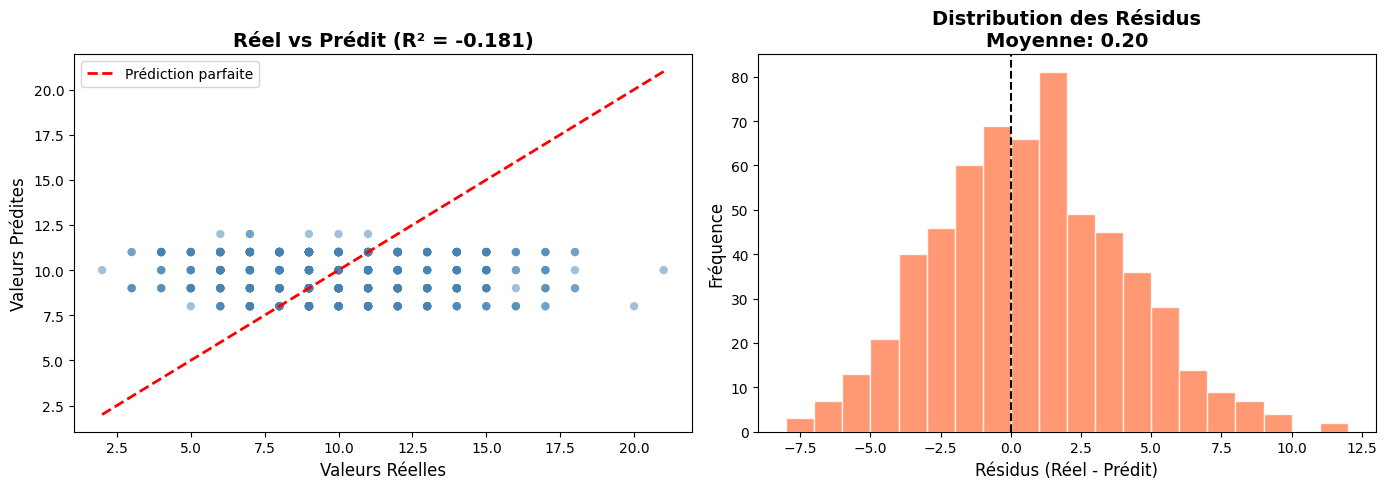

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prédictions vs Valeurs Réelles
axes[0].scatter(y_test, y_pred_base, alpha=0.5, color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs Réelles', fontsize=12)
axes[0].set_ylabel('Valeurs Prédites', fontsize=12)
axes[0].set_title(f'Réel vs Prédit (R² = {r2:.3f})', fontsize=14, fontweight='bold')
axes[0].legend()

# Distribution des Résidus
residuals = y_test - y_pred_base
axes[1].hist(residuals, bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Résidus (Réel - Prédit)', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title(f'Distribution des Résidus\nMoyenne: {residuals.mean():.2f}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [50]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100)


model.fit(X_train, y_train)
model.score(X_test, y_test)



0.13166666666666665

In [51]:
model = RandomForestClassifier(n_estimators=100, max_depth=3)

model.fit(X_train, y_train)
model.score(X_test, y_test)

0.135

In [52]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

best = 0
best_k=0
for k in range (1,100,1):
    model = AdaBoostClassifier(n_estimators=k)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    if(best<score):
        best=score
        best_k=k
    if(score>0.73):
        print(k,score)
print("best : ",best_k,best)

best :  3 0.155


In [53]:
model = AdaBoostClassifier(n_estimators=1)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.115

In [ ]:
from models.random_forest_rgs import run as run_rgs
from models.random_forest_clf import run as run_rf
from models.xgboost_rgs import run as run_xgb
from models.knn_rgs import run as run_knn_rgs
from models.knn_clf import run as run_knn_clf
from models.naive_bayes_rgs import run as run_nb

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

modeles = {
    'KNN'          : run_knn_rgs,
    'Random Forest (clf)': run_rf,
    'Random Forest (rgs)': run_rgs,
    'XGBoost'      : run_xgb,
    'Naive Bayes'  : run_nb,
}

resultats = {}
for nom, run_fn in modeles.items():
    print(f'Entraînement : {nom}...')
    resultats[f'{nom} (LE)']  = run_fn(X_train_le,  X_test_le,  y_train, y_test)
    resultats[f'{nom} (OHE)'] = run_fn(X_train_ohe, X_test_ohe, y_train, y_test)
    print(f"  LE  R²: {resultats[f'{nom} (LE)']['optimized']['r2']:.4f}")
    print(f"  OHE R²: {resultats[f'{nom} (OHE)']['optimized']['r2']:.4f}")


VotingClassifier
print('\nTerminé.')
